In [ ]:
# General imports
import numpy as np
np.random.seed(42)
import pandas as pd


import matplotlib.pyplot as plt
%matplotlib notebook
from matplotlib import colors as mcolors
colors = dict(mcolors.BASE_COLORS, **mcolors.CSS4_COLORS)
import sys
import os
from dotenv import load_dotenv
# Load environment variables from .env file
load_dotenv()
resum_path = os.getenv("RESUM_PATH")
if resum_path is None:
    raise ValueError("Environment variable RESUM_PATH is not set. Make sure to define it in your .env file.")

utilities_path = os.path.join(resum_path, "utilities")
sys.path.append(utilities_path)
import plotting_utils as plotting

import multi_fidelity_visualizer as vis_mfsm
import multi_fidelity_surrogate_model as mfsm

In [2]:
version = 'v1.6'
file_in=f'Ge77_rates_CNP_{version}.csv'
if not os.path.exists(f'{resum_path}/multi-fidelity-gaussian-process/out/{version}'):
   os.makedirs(f'{resum_path}/multi-fidelity-gaussian-process/out/{version}')
if not os.path.exists(f'{resum_path}/multi-fidelity-gaussian-process/in/Ge77_rates_new_samples_{version}.csv'):
   fout = open(f'{resum_path}/in/Ge77_rates_new_samples_{version}.csv')
   fout.write("#\n ,Sample,Mode,Radius[cm],Thickness[cm],NPanels,Theta[deg],Length[cm],Ge-77[nevents],Ge-77_CNP,Ge-77_CNP_err")
   fout.close()
   

# Set parameter name/x_labels -> needs to be consistent with data input file
x_labels=['Radius[cm]','Thickness[cm]','NPanels', 'Theta[deg]', 'Length[cm]']
x_labels_out = ['Radius [cm]','Thickness [cm]','NPanels', 'Angle [deg]', 'Length [cm]']
y_label_cnp = 'Ge-77_CNP'
y_err_label_cnp = 'Ge-77_CNP_err'
y_label_sim = 'rGe77[nuc/(kg*yr)]'

# Set parameter boundaries
xmin=[0,0,0,0,0]
xmax=[265,20,360,90,150]
x_fixed = [160, 2, 40, 45, 20]

# Set parameter boundaries for aquisition function
parameters={'Radius[cm]': [90,250], 'Thickness[cm]':[2,15],'NPanels': [4,360], 'Theta[deg]': [0,90], 'Length[cm]': [1,150]}
parameters_draw={'Radius [cm]': [0,265],'Thickness [cm]': [0,20],'NPanels': [0,360], 'Angle [deg]': [0,90], 'Length [cm]': [0,150]}

# Assign costs
low_fidelity_cost = 1.
high_fidelity_cost = 2000.


In [3]:
data=pd.read_csv(f'{resum_path}/multi-fidelity-gaussian-process/in/{file_in}')

LF_cnp_noise=np.mean(data.loc[data['Mode']==0.][y_err_label_cnp].to_numpy())
HF_cnp_noise=np.mean(data.loc[data['Mode']==1.][y_err_label_cnp].to_numpy())

x_train_l, x_train_h, y_train_l, y_train_h = ([],[],[],[])
row_h=data.index[data['Mode'] == 1].tolist()
row_l=data.index[data['Mode'] == 0].tolist()

x_train_hf_sim = data.loc[data['Mode']==1.][x_labels].to_numpy().tolist()
y_train_hf_sim = data.loc[data['Mode']==1.][y_label_sim].to_numpy().tolist()

x_train_hf_cnp = data.loc[data['Mode']==1.][x_labels].to_numpy().tolist()
y_train_hf_cnp = data.loc[data['Mode']==1.][ y_label_cnp].to_numpy().tolist()

x_train_lf_sim = data.loc[data['Mode']==0.][x_labels].to_numpy().tolist()
y_train_lf_sim = data.loc[data['Mode']==0.][ y_label_sim].to_numpy().tolist()

x_train_lf_cnp = data.loc[data['Mode']==0.][x_labels].to_numpy().tolist()
y_train_lf_cnp = data.loc[data['Mode']==0.][ y_label_cnp].to_numpy().tolist()

trainings_data = {"lf": [x_train_lf_cnp,y_train_lf_cnp], "mf": [x_train_hf_cnp,y_train_hf_cnp], "hf": [x_train_hf_sim,y_train_hf_sim]}
noise = {"lf": LF_cnp_noise, "mf": 0., "hf": 0.}


In [4]:
class NeutronModeratorInequalityConstraints(mfsm.InequalityConstraints):
    def __init__(self, get_inner_radius, get_outer_radius, is_crossed):
        self.get_inner_radius = get_inner_radius
        self.get_outer_radius = get_outer_radius
        self.is_crossed = is_crossed

    def evaluate(self, x):
        super().evaluate(x)
        delta_x = np.ones(len(x))
        for i, xi in enumerate(x[:, :-1]):
            if self.get_inner_radius(xi) < 90.0:
                delta_x[i] = 0.0
            elif self.get_outer_radius(xi) > 265.0:
                delta_x[i] = 0.0
            elif self.get_outer_radius(xi) - self.get_inner_radius(xi) > 20.0:
                delta_x[i] = 0.0
            elif (
                xi[2] * xi[1] * xi[4]
                > 1.05 * np.pi * (self.get_outer_radius(xi)**2 - self.get_inner_radius(xi)**2)
            ):
                delta_x[i] = 0.0
            elif self.is_crossed(xi):
                delta_x[i] = 0.0
            else:
                delta_x[i] = 1.0
        return delta_x[:, None]

In [5]:
inequalities = NeutronModeratorInequalityConstraints(plotting.get_inner_radius, plotting.get_outer_radius, plotting.is_crossed)

In [6]:
mf_model = mfsm.MFGPModel(trainings_data,noise, inequalities)
mf_model.build_model(1)

 /Users/aschuetz/.local/modules/miniconda/miniconda3/envs/legend/lib/python3.10/site-packages/paramz/transformations.py:111: RuntimeWarning:divide by zero encountered in log


In [7]:
mf_model.model.gpy_model

gp.,value,constraints,priors
multifidelity.rbf.variance,0.1897422624258478,+ve,
multifidelity.rbf.lengthscale,236.97062780489583,+ve,
multifidelity.rbf_1.variance,5.562684646268137e-309,+ve,
multifidelity.rbf_1.lengthscale,1.0,+ve,
multifidelity.rbf_2.variance,0.0022455843245877956,+ve,
multifidelity.rbf_2.lengthscale,1.0000000197810428,+ve,
multifidelity.rbf_3.variance,1.0,+ve,
multifidelity.rbf_3.lengthscale,1.0,+ve,
multifidelity.scale,"(3,)",,
mixed_noise.Gaussian_noise.variance,0.021286798679867984,+ve fixed,


In [8]:
%%capture
leg_label = []
ncol=3
nrow=int(np.ceil(len(x_labels)/ncol))
fig2,_  = plt.subplots(nrow, ncol, figsize=(15, 5), constrained_layout=True)
fig4,_  = plt.subplots(int(np.ceil(len(x_labels)/1)), 1, figsize=(5, 12), constrained_layout=True)



In [9]:
mf_vis = vis_mfsm.MultiFidelityVisualizer(mf_model,parameters_draw,x_fixed)

In [10]:

data_new=pd.read_csv(f'in/Ge77_rates_new_samples_{version}.csv')
sample=0
add_new_sample=True
mf_model.set_traings_data(trainings_data)

while ( sample <= data_new['Sample'].max()):
    print('Sample #', sample)

    if sample > 0:    
         
        x_train_hf_sim = data_new[(data_new['Mode']==1.) & (data_new['Sample']==sample)][x_labels].to_numpy().tolist()
        y_train_hf_sim = data_new[(data_new['Mode']==1.) & (data_new['Sample']==sample)][y_label_sim].to_numpy().tolist()
        print(f"Adding {x_train_hf_sim}")   
        x_train_hf_cnp = data_new[(data_new['Mode']==1.) & (data_new['Sample']==sample)][x_labels].to_numpy().tolist()
        y_train_hf_cnp = data_new[(data_new['Mode']==1.) & (data_new['Sample']==sample)][y_label_cnp].to_numpy().tolist()

        x_train_lf_cnp = data_new[(data_new['Mode']==0.) & (data_new['Sample']==sample)][x_labels].to_numpy().tolist()
        y_train_lf_cnp = data_new[(data_new['Mode']==0.) & (data_new['Sample']==sample)][ y_label_cnp].to_numpy().tolist()
        trainings_data_new = {"lf": [x_train_lf_cnp,y_train_lf_cnp], "mf": [x_train_hf_cnp,y_train_hf_cnp], "hf": [x_train_hf_sim,y_train_hf_sim]}
        mf_model.set_data(trainings_data_new)


    # run the model drawing
    fig1, ax = plt.subplots(2, 3,figsize=(15, 5),constrained_layout=True)
    fig1 = mf_vis.draw_model_projections(fig1)
    fig2 = mf_vis.draw_model_projections(fig2)

    # find the next data point
    x_next_sample, us_acquisition = mf_model.max_acquisition_integrated_variance_reduction(parameters)
    print(f'next suggested point to simulated is at: {x_next_sample}')
    fig4 = mf_vis.draw_acquisition_func(fig4, us_acquisition, np.array(x_next_sample))
    sample+=1




Sample # 0


<IPython.core.display.Javascript object>

next suggested point to simulated is at: [[244.17153526   5.84978549  81.18757932  19.35731116  37.59937249
    1.        ]]


 /Users/aschuetz/Documents/Analysis/legend/ML/resum-code/resum/utilities/plotting_utils.py:308: RuntimeWarning:divide by zero encountered in scalar divide
 /Users/aschuetz/Documents/Analysis/legend/ML/resum-code/resum/utilities/plotting_utils.py:319: RuntimeWarning:invalid value encountered in cos
 /Users/aschuetz/Documents/Analysis/legend/ML/resum-code/resum/utilities/plotting_utils.py:320: RuntimeWarning:invalid value encountered in sin
 /Users/aschuetz/Documents/Analysis/legend/ML/resum-code/resum/utilities/plotting_utils.py:321: RuntimeWarning:invalid value encountered in cos
 /Users/aschuetz/Documents/Analysis/legend/ML/resum-code/resum/utilities/plotting_utils.py:322: RuntimeWarning:invalid value encountered in sin
 /Users/aschuetz/Documents/Analysis/legend/ML/resum-code/resum/utilities/plotting_utils.py:323: RuntimeWarning:invalid value encountered in cos
 /Users/aschuetz/Documents/Analysis/legend/ML/resum-code/resum/utilities/plotting_utils.py:324: RuntimeWarning:invalid value 

Sample # 1
Adding [[184.2, 5.1, 218.0, 48.9, 17.8]]


...

next suggested point to simulated is at: [[184.89219287   5.08413292 217.09607275  48.77690618  15.58878871
    1.        ]]


 /Users/aschuetz/Documents/Analysis/legend/ML/resum-code/resum/utilities/plotting_utils.py:308: RuntimeWarning:divide by zero encountered in scalar divide
 /Users/aschuetz/Documents/Analysis/legend/ML/resum-code/resum/utilities/plotting_utils.py:319: RuntimeWarning:invalid value encountered in cos
 /Users/aschuetz/Documents/Analysis/legend/ML/resum-code/resum/utilities/plotting_utils.py:320: RuntimeWarning:invalid value encountered in sin
 /Users/aschuetz/Documents/Analysis/legend/ML/resum-code/resum/utilities/plotting_utils.py:321: RuntimeWarning:invalid value encountered in cos
 /Users/aschuetz/Documents/Analysis/legend/ML/resum-code/resum/utilities/plotting_utils.py:322: RuntimeWarning:invalid value encountered in sin
 /Users/aschuetz/Documents/Analysis/legend/ML/resum-code/resum/utilities/plotting_utils.py:323: RuntimeWarning:invalid value encountered in cos
 /Users/aschuetz/Documents/Analysis/legend/ML/resum-code/resum/utilities/plotting_utils.py:324: RuntimeWarning:invalid value 

Sample # 2
Adding [[202.4, 2.7, 29.0, 10.4, 78.7]]


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [ ]:
%matplotlib inline
fig2.show()
fig4.show()

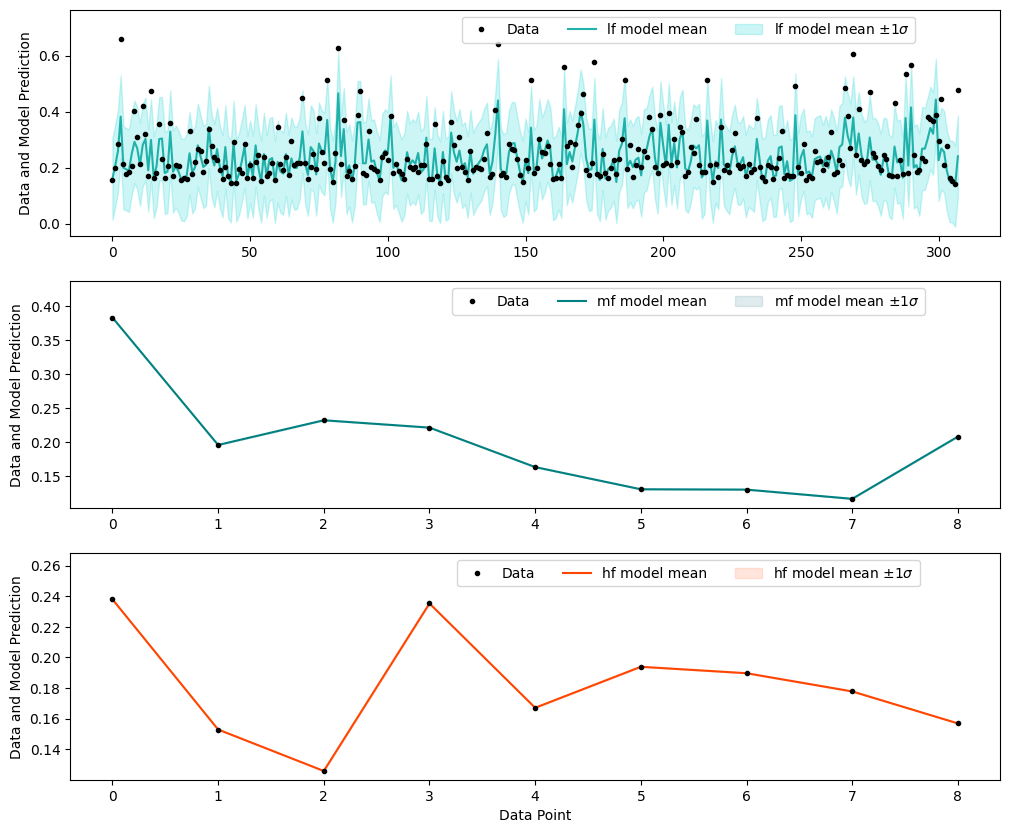

In [ ]:
fig3 = mf_vis.draw_model()

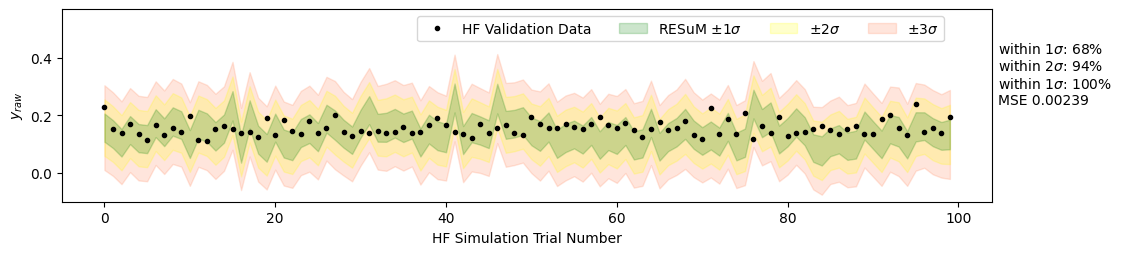

In [ ]:
data_test=pd.read_csv(f'{resum_path}/multi-fidelity-gaussian-process/in/hf_validation_data_v1.2.csv')
x_test = data_test.loc[data_test['Mode']==1.][x_labels].to_numpy().tolist()
y_test = data_test.loc[data_test['Mode']==1.][y_label_sim].to_numpy().tolist()
fig5, validation  = mf_vis.model_validation(x_test, y_test)
plt.show()


x_fmin = [150,10,360,0,3]
f_min = 1.
dx_fmin=[]
dy_fmin=[]
dsigma_fmin=[]
for i in range(50):
    x_fmin_tmp, f_min_tmp = mf_model.get_min_constrained(parameters,[150.,10.,360.,0.,4.],2)
    #plotting.draw_moderator_configuration(x_fmin_tmp)
    dx_fmin.append(x_fmin_tmp)
    dy_fmin.append(f_min_tmp)
    dsigma_fmin.append(mf_model.evaluate_model_uncertainty(x_fmin_tmp,2))
    print(f"minimum found at {x_fmin_tmp} with f = {f_min_tmp} {mf_model.evaluate_model(x_fmin_tmp,2)} +- {mf_model.evaluate_model_uncertainty(x_fmin_tmp,2)} and a reduction of {mf_model.evaluate_model([0.,0.,0.,0.,0.],2)/f_min_tmp}")

    if f_min_tmp <= f_min:
        x_fmin = x_fmin_tmp
        f_min = f_min_tmp

    itmp=201+i
    sim.print_geant4_macro(x_fmin_tmp,f"{itmp}",mode="LF",version=f"{version}")


print(f"minimum found at {x_fmin} with f = {f_min} and a reduction of {mf_model.evaluate_model([0.,0.,0.,0.,0.], 2)/f_min}")
print("high fidelity", mf_model.evaluate_model(x_fmin,2), mf_model.evaluate_model([x_fmin[0],plotting.get_outer_radius(x_fmin)-plotting.get_inner_radius(x_fmin),360,0.,4.],2))
print("medium fidelity", mf_model.evaluate_model(x_fmin,1), mf_model.evaluate_model([x_fmin[0],plotting.get_outer_radius(x_fmin)-plotting.get_inner_radius(x_fmin),360,0.,10.],1))
plotting.draw_moderator_configuration(x_fmin)
